In [1]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sb

In [2]:
df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
subset = df[df.datasets == 'mnfinder_validation']
subset.filenames.to_list()[0]

'2022-05-26_RPE1-2198.tif'

In [3]:
df.datasets.unique()

array(['mnDINO_data_02', 'mnDINO_data_01', 'mnfinder_train',
       'mnfinder_test', 'mnfinder_validation', 'BBBC039'], dtype=object)

In [4]:
df.cell_line.unique()

array(['HeLa', 'RPE1', 'MCC13', 'U2OS', 'HFF'], dtype=object)

- screen

In [5]:
path = '/scr/yren/annotated_mn_datasets/validation/'
screen_path = path + 'images/C2-20X_c0-DAPI-GFP_A2_Tile-5.tif'
screen_gt_path = path + 'mn_masks/C2-20X_c0-DAPI-GFP_A2_Tile-5.png'
mndino_path = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/figure4/mndino_predictions/C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy'

input_screen = skimage.io.imread(screen_path)
gt_screen = skimage.io.imread(screen_gt_path)
nuclei_gt_screen = skimage.io.imread(screen_path.replace('images','nuclei_masks'))
mndino_screen = np.load(mndino_path)
mnfinder_screen = np.load(mndino_path.replace('mndino_predictions', 'mnfinder_predictions'))
cellpose_screen = np.load(mndino_path.replace('mndino_predictions', 'cellpose_predictions'))
microsam_screen = np.load(mndino_path.replace('mndino_predictions', 'microSAM_predictions'))

- BBBC039

In [6]:
imid = 'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1'
bbbc039_path = path + f'images/{imid}.tif'
bbbc039_gt_path = path + f'mn_masks/{imid}.png'
mndino_path = f'/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/figure4/mndino_predictions/{imid}._probabilities.npy'

input_bbbc039 = skimage.io.imread(bbbc039_path)
gt_bbbc039 = skimage.io.imread(bbbc039_gt_path)
nuclei_gt_bbbc039 = skimage.io.imread(bbbc039_path.replace('images','nuclei_masks'))
mndino_bbbc039 = np.load(mndino_path)
mnfinder_bbbc039 = np.load(mndino_path.replace('mndino_predictions', 'mnfinder_predictions'))
cellpose_bbbc039 = np.load(mndino_path.replace('mndino_predictions', 'cellpose_predictions'))
microsam_bbbc039 = np.load(mndino_path.replace('mndino_predictions', 'microSAM_predictions'))

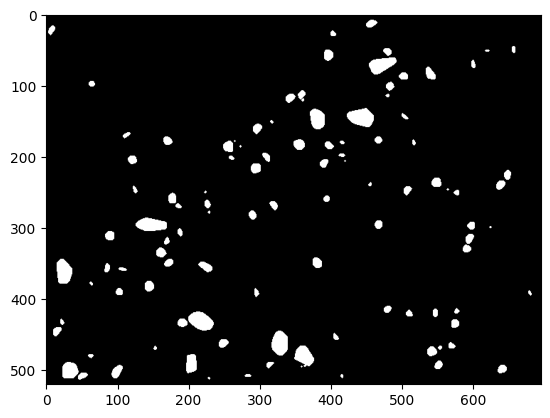

In [7]:
plt.imshow(mnfinder_bbbc039 > 0, cmap='gray')

- HeLa & RPE1

In [8]:
imid = 'C1-20X_c0_B3_Tile-24'
hela_rpe1_path = path + f'images/{imid}.tif'
hela_rpe1_gt_path = path + f'mn_masks/{imid}.png'
mndino_path = f'/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/figure4/mndino_predictions/{imid}._probabilities.npy'

input_hela_rpe1 = skimage.io.imread(hela_rpe1_path)
gt_hela_rpe1 = skimage.io.imread(hela_rpe1_gt_path)
nuclei_gt_hela_rpe1 = skimage.io.imread(hela_rpe1_path.replace('images','nuclei_masks'))
mndino_hela_rpe1 = np.load(mndino_path)
mnfinder_hela_rpe1 = np.load(mndino_path.replace('mndino_predictions', 'mnfinder_predictions'))
cellpose_hela_rpe1 = np.load(mndino_path.replace('mndino_predictions', 'cellpose_predictions'))
microsam_hela_rpe1 = np.load(mndino_path.replace('mndino_predictions', 'microSAM_predictions'))

- MNFinder Data

In [9]:
imid = '2022-05-26_RPE1-2198'
mnfinder_path = path + f'images/{imid}.tif'
mnfinder_gt_path = path + f'mn_masks/{imid}.png'
mndino_path = f'/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/figure4/mndino_predictions/{imid}._probabilities.npy'

input_mnfinder = skimage.io.imread(mnfinder_path)
gt_mnfinder = skimage.io.imread(mnfinder_gt_path)
nuclei_gt_mnfinder = skimage.io.imread(mnfinder_path.replace('images','nuclei_masks'))
mndino_mnfinder = np.load(mndino_path)
mnfinder_mnfinder = np.load(mndino_path.replace('mndino_predictions', 'mnfinder_predictions'))
cellpose_mnfinder = np.load(mndino_path.replace('mndino_predictions', 'cellpose_predictions'))
microsam_mnfinder = np.load(mndino_path.replace('mndino_predictions', 'microSAM_predictions'))

In [10]:
print(gt_screen.shape)
print(gt_bbbc039.shape)
print(gt_hela_rpe1.shape)
print(gt_mnfinder.shape)

(2960, 2960)
(520, 696)
(2720, 2720)
(768, 869)


# Grid Plot

# Add the nuclei mask first, remember to be gray not white

In [11]:
inputs = [input_bbbc039, input_mnfinder, input_screen, input_hela_rpe1]
gt = [gt_bbbc039,  gt_mnfinder, gt_screen, gt_hela_rpe1]
gt_nuclei = [nuclei_gt_bbbc039, nuclei_gt_mnfinder, nuclei_gt_screen, nuclei_gt_hela_rpe1]
mndino = [mndino_bbbc039, mndino_mnfinder, mndino_screen, mndino_hela_rpe1]
mnfinder = [mnfinder_bbbc039,mnfinder_mnfinder, mnfinder_screen, mnfinder_hela_rpe1]
cellpose = [cellpose_bbbc039, cellpose_mnfinder, cellpose_screen, cellpose_hela_rpe1]
microsam = [microsam_bbbc039, microsam_mnfinder, microsam_screen, microsam_hela_rpe1]

In [12]:
mndino_2 = []
for i in range(len(gt_nuclei)):
    H, W = mndino[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (mndino[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive, illusional prediction
    gt_only = gt_mask & ~pred_mask # false negative, missing object

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [0, 255, 0]
    im[pred_only] = [255, 0, 0]
    # im[pred_mask] = [0, 255, 0]
    im[gt_only] = [255, 255, 0] # yellow

    mndino_2.append(im)


In [13]:
gt_2 = []
for i in range(len(gt_nuclei)):
    H, W = gt[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    nuclei_mask = (gt_nuclei[i] > 0)
    gt_mask     = (gt[i] > 0)

    im[nuclei_mask] = [128, 128, 128]
    im[gt_mask] = [238, 130, 238] # color: violet

    gt_2.append(im)


In [14]:
mnfinder_2 = []
for i in range(len(gt_nuclei)):
    H, W = mnfinder[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (mnfinder[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive, illusional prediction
    gt_only = gt_mask & ~pred_mask # false negative, missing object

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [0, 255, 0] # green
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [255, 255, 0] # yellow: missing object

    mnfinder_2.append(im)


In [15]:
cellpose_2 = []
for i in range(len(gt_nuclei)):
    H, W = cellpose[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (cellpose[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [0, 255, 0]
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [255, 255, 0]

    cellpose_2.append(im)


In [16]:
microsam_2 = []
for i in range(len(gt_nuclei)):
    H, W = microsam[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (microsam[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # gray nuclei
    im[nuclei_mask] = [128, 128, 128]
    im[overlap] = [0, 255, 0]
    im[pred_only] = [255, 0, 0]
    im[gt_only] = [255, 255, 0]

    microsam_2.append(im)


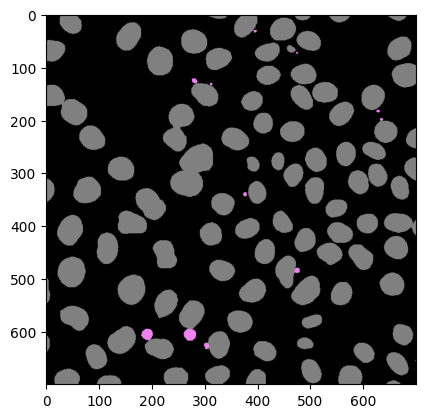

In [17]:
plt.imshow(gt_2[2][2100:2100+700, 1300:1300+700, :], cmap='gray')

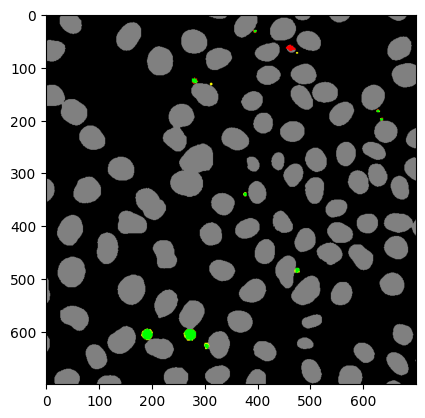

In [18]:
plt.imshow(mndino_2[2][2100:2100+700, 1300:1300+700,:] )

In [19]:
collections = [inputs, gt_2, mndino_2, mnfinder_2, cellpose_2, microsam_2]

In [20]:
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

- Prepare scale bar

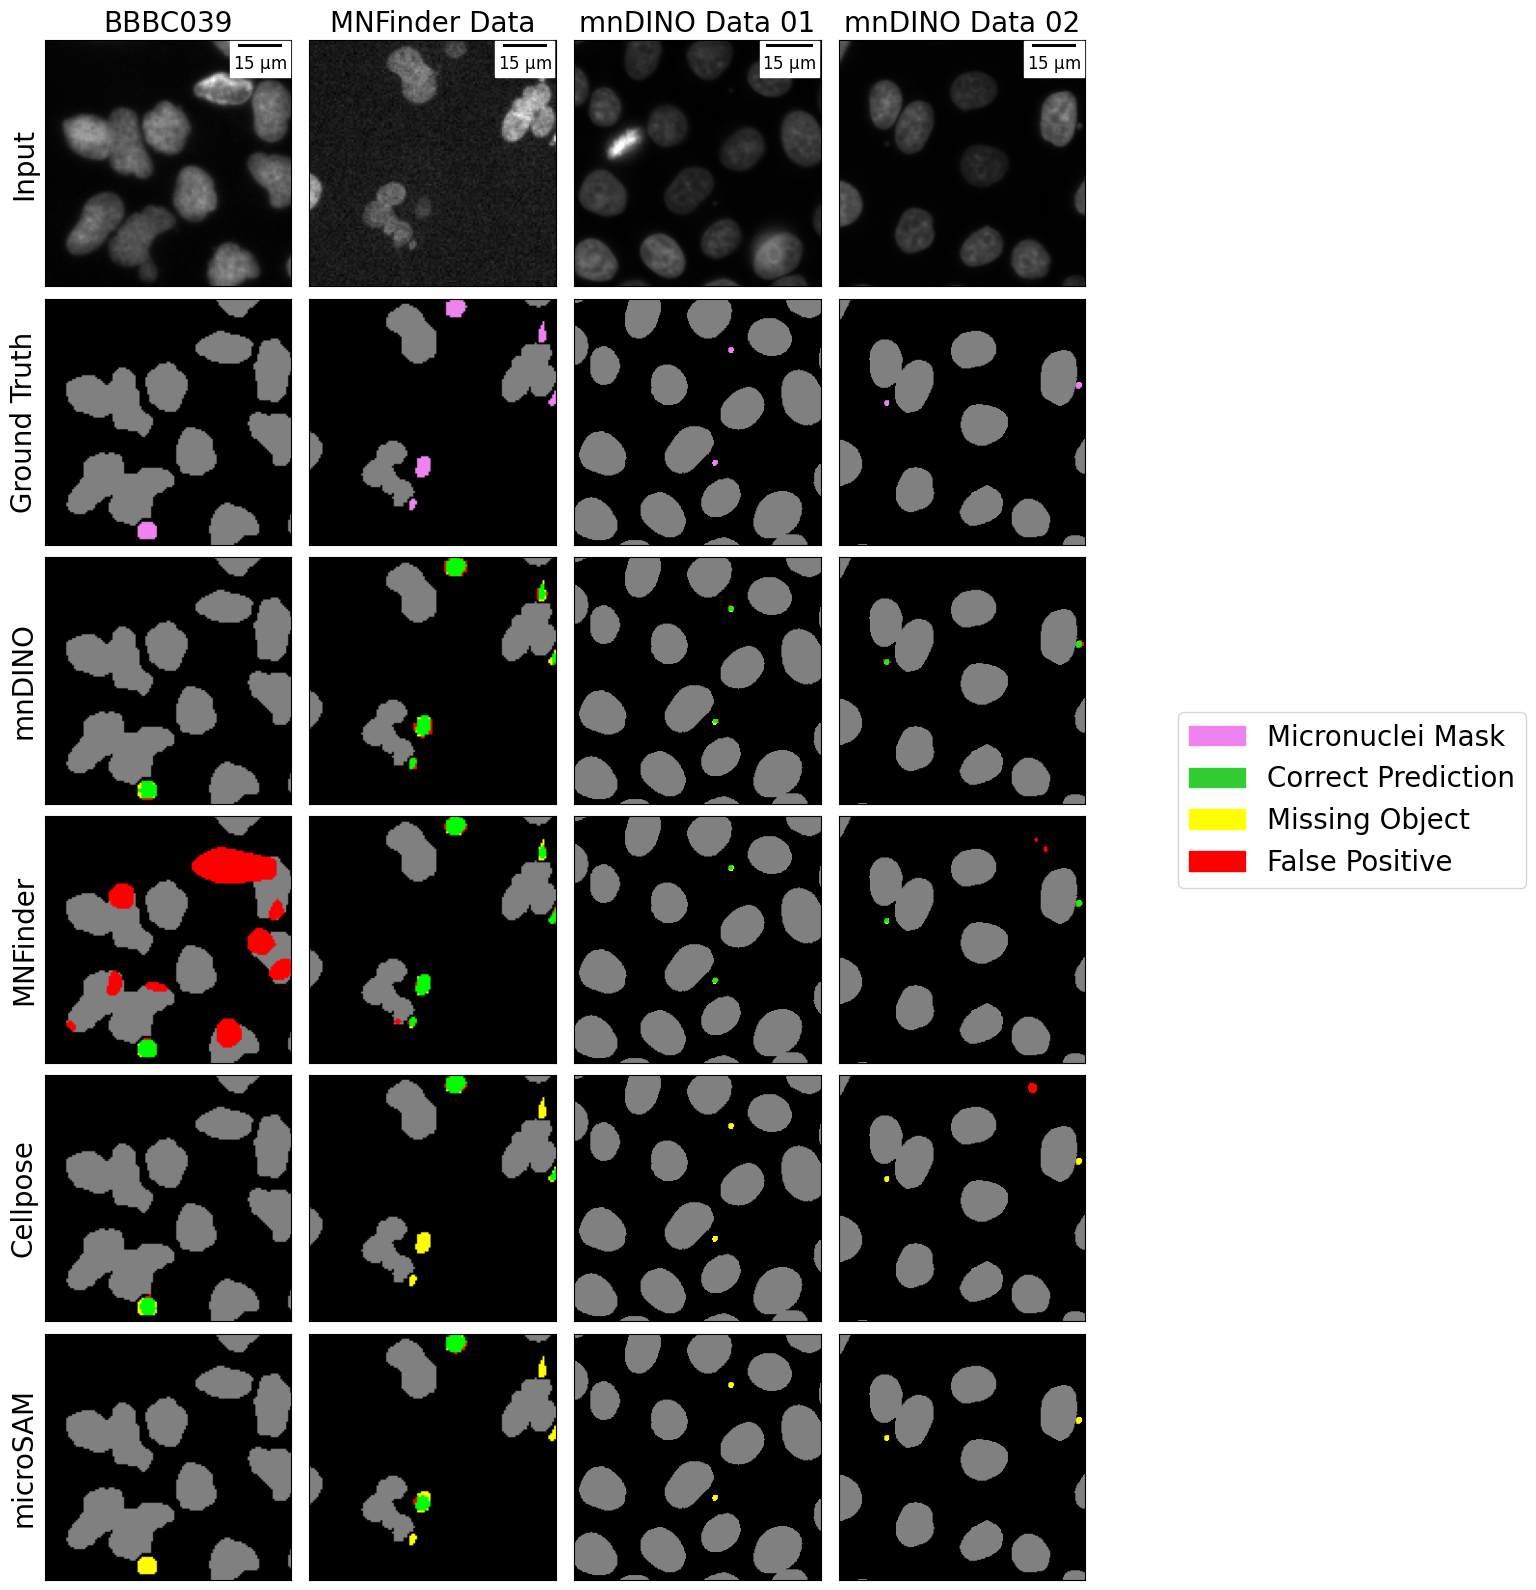

In [41]:
fig, ax = plt.subplots(6,4, figsize=(20,20))
font_dict = {'size': 12}
plt.subplots_adjust(wspace=-0.65, hspace=0.05)

legend_elements = [mpatches.Patch(color='violet', label='Micronuclei Mask'),
                   mpatches.Patch(color='limegreen', label='Correct Prediction'),
                   mpatches.Patch(color='yellow', label='Missing Object'),
                   mpatches.Patch(color='red', label='False Positive')]

# Add the legend to the plot
fig.legend(handles=legend_elements, loc='right', bbox_to_anchor=(1, 0.5), prop=fontprops)

real_world_pixel_size = [13.1/20, 13.0/20, 4.25/14, 6.5/20]
col_labels = ['BBBC039', 'MNFinder Data', 'mnDINO Data 01',  'mnDINO Data 02']
row_labels = ['Input', 'Ground Truth', 'mnDINO', 'MNFinder', 'Cellpose', 'microSAM']

for i in range(6):
    for j in range(4):
        if j==0: # BBBC039
            r,c = 270,50
        elif j == 1: # MNFinder
            r,c = 220,240
        elif j == 2: # Pilot Screen
            r,c = 2400,2050
        elif j == 3: # HeLa RPE1
            r,c = 1700,1950
        if i == 0:
            if (j == 2) or (j == 3):
                PS = 256
            elif (j == 1):
                PS = 128
            else:
                PS=128
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS], cmap='gray')
        else:
            if (j == 2) or (j == 3):
                PS = 256
            elif (j == 1):
                PS = 128
            else:
                PS=128
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS,:])

        # Hide ticks but keep labels
        ax[i, j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if i == 0:
            ax[i, j].set_title(col_labels[j], fontsize=20)
            # add scalebar, Use Scalebar library
            scalebar = ScaleBar(real_world_pixel_size[j], 'um', font_properties=font_dict)
            ax[i, j].add_artist(scalebar)
            

        # Set row labels on the left side
        if j == 0:
            # ax[i, j].set_ylabel(row_labels[i], fontsize=10, rotation=0, labelpad=30, va='center')
            ax[i, j].set_ylabel(row_labels[i], fontsize=20, rotation=90, va='center', labelpad=15)


plt.show()

In [22]:
# plt.savefig('/scr/yren/mndino_figure4.png', transparent=True)

# Cell Line Info

In [23]:
df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
df.head()

mndino_01 = 'C2-20X_c0-DAPI-GFP_A2_Tile-5.tif'
bbbc039 = 'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1.tif'
mndino_02 = 'C1-20X_c0_B3_Tile-24.tif'
mnfinder = '2022-05-26_RPE1-2198.tif'
images = [mndino_01, mndino_02, bbbc039, mnfinder]

df[df.filenames.isin(images)]

,filenames,datasets,magnification,micron,split,cell_line
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.50,validation,HeLa
15,C2-20X_c0-DAPI-GFP_A2_Tile-5.tif,mnDINO_data_01,14,4.25,validation,HeLa
70,2022-05-26_RPE1-2198.tif,mnfinder_validation,20,13.00,validation,RPE1
104,IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B8...,BBBC039,20,13.10,validation,U2OS
